In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.nn.functional as F

# Data Pre-processing

### Loading the train and test dataset with following transformations:

#### Train dataset:
1.   Horizontal Flip
2.   Random Cropping
3.   Color Jittering
4.   Converting to tensor
5.   Normalizing using the mean and standard deviation obtained above

#### Test dataset:
1.   Converting to tensor
2.   Normalizing using the mean and standard deviation obtained above

b. Convert labels into one-hot encoded vectors and split the data into training, validation, and testing subsets.

In [ ]:
# Convert labels to one-hot encoded vectors
def one_hot_encode(labels, num_classes=100):
    return F.one_hot(torch.tensor(labels), num_classes=num_classes)

# Apply one-hot encoding to the training and testing labels
train_dataset.targets = one_hot_encode(train_dataset.targets)
test_dataset.targets = one_hot_encode(test_dataset.targets)

# Split the training dataset into training and validation subsets
train_size = int(0.8 * len(train_dataset))  # 80% for training
val_size = len(train_dataset) - train_size  # 20% for validation
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# Create DataLoaders for training, validation, and testing
batch_size = 64  # Number of samples per batch
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)  # Shuffle the training data
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)  # Do not shuffle the validation data
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)  # Do not shuffle the testing data

# Print dataset details
print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Testing dataset size: {len(test_dataset)}")
print(f"Number of classes: {len(train_dataset.dataset.targets[0])}")  # Number of classes (100 for CIFAR-100)

Training dataset size: 40000
Validation dataset size: 10000
Testing dataset size: 10000
Number of classes: 100


## CIFAR-10 Dataset

## Training the model on CIFAR-10 Dataset and finding best hyperparameters

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Define transformations for the training and testing datasets
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Randomly flip the image horizontally
    transforms.RandomCrop(32, padding=4),  # Randomly crop the image
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),  # Normalize with CIFAR-10 mean and std
])

transform_test = transforms.Compose([
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),  # Normalize with CIFAR-10 mean and std
])

# Load the CIFAR-10 training dataset
train_dataset = datasets.CIFAR10(
    root='./data',  # Path to store the dataset
    train=True,  # Load the training set
    download=True,  # Download the dataset if it doesn't exist
    transform=transform_train,  # Apply the training transformations
)

# Load the CIFAR-10 testing dataset
test_dataset = datasets.CIFAR10(
    root='./data',  # Path to store the dataset
    train=False,  # Load the testing set
    download=True,  # Download the dataset if it doesn't exist
    transform=transform_test,  # Apply the testing transformations
)

# Split the training dataset into training and validation subsets
train_size = int(0.8 * len(train_dataset))  # 80% for training
val_size = len(train_dataset) - train_size  # 20% for validation
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# Create DataLoaders for training, validation, and testing
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Define the CNN model
class CNN(nn.Module):
    def __init__(self, activation='relu', kernel_size=3, num_classes=10):
        super(CNN, self).__init__()
        self.activation = activation
        self.conv1 = nn.Conv2d(3, 32, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn4 = nn.BatchNorm2d(256)
        self.fc1 = nn.Linear(256 * 8 * 8, 1024)
        self.fc2 = nn.Linear(1024, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.apply_activation(self.bn1(self.conv1(x)))
        x = self.pool(self.apply_activation(self.bn2(self.conv2(x))))
        x = self.apply_activation(self.bn3(self.conv3(x)))
        x = self.pool(self.apply_activation(self.bn4(self.conv4(x))))
        x = x.view(x.size(0), -1)  # Flatten
        x = self.dropout(self.apply_activation(self.fc1(x)))
        x = self.fc2(x)
        return x

    def apply_activation(self, x):
        if self.activation == 'relu':
            return F.relu(x)
        elif self.activation == 'leaky_relu':
            return F.leaky_relu(x, negative_slope=0.1)
        elif self.activation == 'gelu':
            return F.gelu(x)
        else:
            raise ValueError(f"Unsupported activation: {self.activation}")

# Hyperparameters to tune
activations = ['relu', 'leaky_relu', 'gelu']
kernel_sizes = [3, 5]
optimizers_list = ['adam', 'sgd']

# Store results
results = []

# Hyperparameter tuning loop
for activation in activations:
    for kernel_size in kernel_sizes:
        for optimizer_name in optimizers_list:
            print(f"\nTraining with activation={activation}, kernel_size={kernel_size}, optimizer={optimizer_name}")

            # Create the model
            model = CNN(activation=activation, kernel_size=kernel_size, num_classes=10).to(device)

            # Define loss function and optimizer
            criterion = nn.CrossEntropyLoss()
            if optimizer_name == 'adam':
                optimizer = optim.Adam(model.parameters(), lr=0.001)
            elif optimizer_name == 'sgd':
                optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
            else:
                raise ValueError(f"Unsupported optimizer: {optimizer_name}")

            scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)

            # Training loop
            num_epochs = 10  # Train for fewer epochs for tuning
            best_val_accuracy = 0.0

            for epoch in range(num_epochs):
                model.train()
                running_loss = 0.0
                correct = 0
                total = 0

                for inputs, labels in train_loader:
                    inputs, labels = inputs.to(device), labels.to(device)

                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()

                    running_loss += loss.item()

                    _, predicted = torch.max(outputs, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

                train_loss = running_loss / len(train_loader)
                train_accuracy = 100 * correct / total

                # Validation loop
                model.eval()
                val_loss = 0.0
                correct = 0
                total = 0

                with torch.no_grad():
                    for inputs, labels in val_loader:
                        inputs, labels = inputs.to(device), labels.to(device)

                        outputs = model(inputs)
                        loss = criterion(outputs, labels)
                        val_loss += loss.item()

                        _, predicted = torch.max(outputs, 1)
                        total += labels.size(0)
                        correct += (predicted == labels).sum().item()

                val_loss = val_loss / len(val_loader)
                val_accuracy = 100 * correct / total

                # Save the best validation accuracy
                if val_accuracy > best_val_accuracy:
                    best_val_accuracy = val_accuracy

                print(f"Epoch [{epoch+1}/{num_epochs}], "
                      f"Training Loss: {train_loss:.4f}, "
                      f"Validation Loss: {val_loss:.4f}, "
                      f"Validation Accuracy: {val_accuracy:.2f}%")

                # Step the learning rate scheduler
                scheduler.step(val_loss)

            # Store the results
            results.append({
                'activation': activation,
                'kernel_size': kernel_size,
                'optimizer': optimizer_name,
                'best_val_accuracy': best_val_accuracy
            })

# Print the results
print("\nHyperparameter Tuning Results:")
for result in results:
    print(result)

# Find the best model
best_result = max(results, key=lambda x: x['best_val_accuracy'])
print(f"\nBest Model: {best_result}")

Using device: cuda


100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]



Training with activation=relu, kernel_size=3, optimizer=adam
Epoch [1/10], Training Loss: 2.3096, Validation Loss: 1.7219, Validation Accuracy: 36.41%
Epoch [2/10], Training Loss: 1.6126, Validation Loss: 1.9599, Validation Accuracy: 32.98%
Epoch [3/10], Training Loss: 1.4488, Validation Loss: 1.3738, Validation Accuracy: 51.89%
Epoch [4/10], Training Loss: 1.3193, Validation Loss: 1.2397, Validation Accuracy: 53.84%
Epoch [5/10], Training Loss: 1.2183, Validation Loss: 1.0688, Validation Accuracy: 61.81%
Epoch [6/10], Training Loss: 1.1360, Validation Loss: 1.0769, Validation Accuracy: 61.57%
Epoch [7/10], Training Loss: 1.0751, Validation Loss: 1.0222, Validation Accuracy: 64.32%
Epoch [8/10], Training Loss: 1.0289, Validation Loss: 1.0889, Validation Accuracy: 63.85%
Epoch [9/10], Training Loss: 0.9810, Validation Loss: 1.0203, Validation Accuracy: 64.18%
Epoch [10/10], Training Loss: 0.9472, Validation Loss: 0.8451, Validation Accuracy: 70.31%

Training with activation=relu, kerne

# Training model on CIFAR-10 dataset with the best parameters observed above but with more epochs and early stopping

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Define transformations
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

# Load dataset
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Split into training & validation
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# DataLoader
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Define CNN model
class CNN(nn.Module):
    def __init__(self, activation='relu', kernel_size=3, num_classes=10):
        super(CNN, self).__init__()
        self.activation = activation
        self.conv1 = nn.Conv2d(3, 32, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn4 = nn.BatchNorm2d(256)
        self.fc1 = nn.Linear(256 * 8 * 8, 1024)
        self.fc2 = nn.Linear(1024, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.apply_activation(self.bn1(self.conv1(x)))
        x = self.pool(self.apply_activation(self.bn2(self.conv2(x))))
        x = self.apply_activation(self.bn3(self.conv3(x)))
        x = self.pool(self.apply_activation(self.bn4(self.conv4(x))))
        x = x.view(x.size(0), -1)  # Flatten
        x = self.dropout(self.apply_activation(self.fc1(x)))
        x = self.fc2(x)
        return x

    def apply_activation(self, x):
        if self.activation == 'relu':
            return nn.ReLU()(x)
        elif self.activation == 'leaky_relu':
            return nn.LeakyReLU(negative_slope=0.1)(x)
        elif self.activation == 'gelu':
            return nn.GELU()(x)
        else:
            raise ValueError(f"Unsupported activation: {self.activation}")

# Early stopping class
class EarlyStopping:
    def __init__(self, patience=5, delta=0.001):
        self.patience = patience
        self.delta = delta
        self.best_loss = np.inf
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss, model, model_path='best_model.pth'):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), model_path)  # Save best model
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

# Hyperparameters
activations = ['leaky_relu']
kernel_sizes = [5]
optimizers_list = ['sgd']
results = []

# Hyperparameter tuning
for activation in activations:
    for kernel_size in kernel_sizes:
        for optimizer_name in optimizers_list:
            print(f"\nTraining with activation={activation}, kernel_size={kernel_size}, optimizer={optimizer_name}")

            # Create model
            model = CNN(activation=activation, kernel_size=kernel_size, num_classes=10).to(device)

            # Define optimizer and loss function
            criterion = nn.CrossEntropyLoss()
            if optimizer_name == 'adam':
                optimizer = optim.Adam(model.parameters(), lr=0.001)
            elif optimizer_name == 'sgd':
                optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
            else:
                raise ValueError(f"Unsupported optimizer: {optimizer_name}")

            scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)
            early_stopping = EarlyStopping(patience=5)

            # Lists to store loss and accuracy
            train_losses, val_losses, val_accuracies = [], [], []

            # Training loop
            num_epochs = 100
            best_val_accuracy = 0.0

            for epoch in range(num_epochs):
                model.train()
                running_loss = 0.0
                correct, total = 0, 0

                for inputs, labels in train_loader:
                    inputs, labels = inputs.to(device), labels.to(device)

                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()

                    running_loss += loss.item()
                    _, predicted = torch.max(outputs, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

                train_loss = running_loss / len(train_loader)
                train_accuracy = 100 * correct / total

                # Validation loop
                model.eval()
                val_loss = 0.0
                correct, total = 0, 0

                with torch.no_grad():
                    for inputs, labels in val_loader:
                        inputs, labels = inputs.to(device), labels.to(device)
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)
                        val_loss += loss.item()
                        _, predicted = torch.max(outputs, 1)
                        total += labels.size(0)
                        correct += (predicted == labels).sum().item()

                val_loss = val_loss / len(val_loader)
                val_accuracy = 100 * correct / total

                # Store losses & accuracy
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                val_accuracies.append(val_accuracy)

                # Check early stopping
                early_stopping(val_loss, model)
                if early_stopping.early_stop:
                    print("✅ Early stopping triggered.")
                    break

                print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")
                scheduler.step(val_loss)

            # Save for visualization
            np.save('train_losses.npy', train_losses)
            np.save('val_losses.npy', val_losses)
            np.save('val_accuracies.npy', val_accuracies)


Using device: cuda

Training with activation=leaky_relu, kernel_size=5, optimizer=sgd
Epoch [1/100], Train Loss: 1.6406, Val Loss: 1.4527, Val Acc: 47.44%
Epoch [2/100], Train Loss: 1.2912, Val Loss: 1.2340, Val Acc: 56.62%
Epoch [3/100], Train Loss: 1.1007, Val Loss: 0.9895, Val Acc: 64.53%
Epoch [4/100], Train Loss: 0.9750, Val Loss: 0.8858, Val Acc: 68.19%
Epoch [5/100], Train Loss: 0.8969, Val Loss: 0.8524, Val Acc: 69.99%
Epoch [6/100], Train Loss: 0.8294, Val Loss: 0.9078, Val Acc: 68.29%
Epoch [7/100], Train Loss: 0.7723, Val Loss: 0.8075, Val Acc: 72.08%
Epoch [8/100], Train Loss: 0.7315, Val Loss: 0.7429, Val Acc: 74.36%
Epoch [9/100], Train Loss: 0.6906, Val Loss: 0.7415, Val Acc: 74.44%
Epoch [10/100], Train Loss: 0.6533, Val Loss: 0.6350, Val Acc: 78.15%
Epoch [11/100], Train Loss: 0.6228, Val Loss: 0.7279, Val Acc: 75.44%
Epoch [12/100], Train Loss: 0.5909, Val Loss: 0.6782, Val Acc: 77.21%
Epoch [13/100], Train Loss: 0.5670, Val Loss: 0.6282, Val Acc: 79.11%
Epoch [14/100

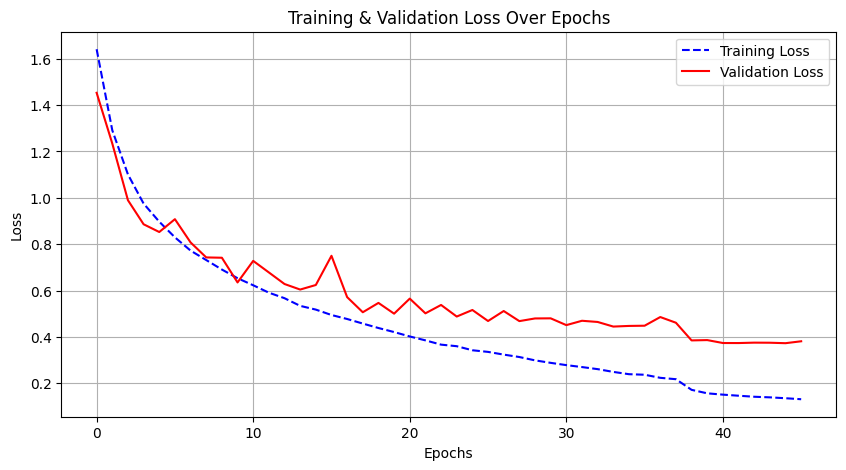

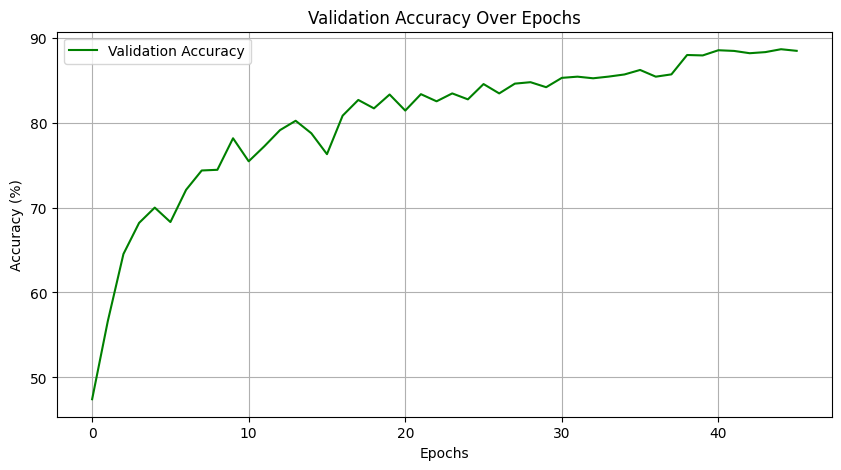

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Load the stored training results
train_losses = np.load("train_losses.npy")
val_losses = np.load("val_losses.npy")
val_accuracies = np.load("val_accuracies.npy")

# Plot Training & Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', color='blue', linestyle='dashed')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Plot Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy Over Epochs')
plt.legend()
plt.grid(True)
plt.show()


The best validation accuracy that we got from this model is 88.63%.

# CIFAR-100 dataset

## Training the model with 10 epochs and multiple hyperparameters

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Define transformations for the training and testing datasets
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Horizontal flipping
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Color jittering
    transforms.RandomCrop(32, padding=4),  # Randomly crop the image
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),  # Normalize with CIFAR-100 mean and std
])

transform_test = transforms.Compose([
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),  # Normalize with CIFAR-100 mean and std
])

# Load the CIFAR-100 training dataset
train_dataset = datasets.CIFAR100(
    root='./data',  # Path to store the dataset
    train=True,  # Load the training set
    download=True,  # Download the dataset if it doesn't exist
    transform=transform_train,  # Apply the training transformations
)

# Load the CIFAR-100 testing dataset
test_dataset = datasets.CIFAR100(
    root='./data',  # Path to store the dataset
    train=False,  # Load the testing set
    download=True,  # Download the dataset if it doesn't exist
    transform=transform_test,  # Apply the testing transformations
)

# Split the training dataset into training and validation subsets
train_size = int(0.8 * len(train_dataset))  # 80% for training
val_size = len(train_dataset) - train_size  # 20% for validation
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# Create DataLoaders for training, validation, and testing
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Define the CNN model
class CNN(nn.Module):
    def __init__(self, activation='relu', kernel_size=3, num_classes=100):
        super(CNN, self).__init__()
        self.activation = activation
        self.conv1 = nn.Conv2d(3, 32, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn4 = nn.BatchNorm2d(256)
        self.fc1 = nn.Linear(256 * 8 * 8, 1024)
        self.fc2 = nn.Linear(1024, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.apply_activation(self.bn1(self.conv1(x)))
        x = self.pool(self.apply_activation(self.bn2(self.conv2(x))))
        x = self.apply_activation(self.bn3(self.conv3(x)))
        x = self.pool(self.apply_activation(self.bn4(self.conv4(x))))
        x = x.view(x.size(0), -1)  # Flatten
        x = self.dropout(self.apply_activation(self.fc1(x)))
        x = self.fc2(x)
        return x

    def apply_activation(self, x):
        if self.activation == 'relu':
            return F.relu(x)
        elif self.activation == 'leaky_relu':
            return F.leaky_relu(x, negative_slope=0.1)
        elif self.activation == 'gelu':
            return F.gelu(x)
        else:
            raise ValueError(f"Unsupported activation: {self.activation}")

# Hyperparameters to tune
activations = ['relu', 'leaky_relu', 'gelu']
kernel_sizes = [3, 5]
optimizers_list = ['adam', 'sgd']

# Store results
results = []

# Hyperparameter tuning loop
for activation in activations:
    for kernel_size in kernel_sizes:
        for optimizer_name in optimizers_list:
            print(f"\nTraining with activation={activation}, kernel_size={kernel_size}, optimizer={optimizer_name}")

            # Create the model
            model = CNN(activation=activation, kernel_size=kernel_size, num_classes=100).to(device)

            # Define loss function and optimizer
            criterion = nn.CrossEntropyLoss()
            if optimizer_name == 'adam':
                optimizer = optim.Adam(model.parameters(), lr=0.001)
            elif optimizer_name == 'sgd':
                optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
            else:
                raise ValueError(f"Unsupported optimizer: {optimizer_name}")

            scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)

            # Training loop
            num_epochs = 10  # Train for fewer epochs for tuning
            best_val_accuracy = 0.0

            for epoch in range(num_epochs):
                model.train()
                running_loss = 0.0
                correct = 0
                total = 0

                for inputs, labels in train_loader:
                    inputs, labels = inputs.to(device), labels.to(device)

                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()

                    running_loss += loss.item()

                    _, predicted = torch.max(outputs, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

                train_loss = running_loss / len(train_loader)
                train_accuracy = 100 * correct / total

                # Validation loop
                model.eval()
                val_loss = 0.0
                correct = 0
                total = 0

                with torch.no_grad():
                    for inputs, labels in val_loader:
                        inputs, labels = inputs.to(device), labels.to(device)

                        outputs = model(inputs)
                        loss = criterion(outputs, labels)
                        val_loss += loss.item()

                        _, predicted = torch.max(outputs, 1)
                        total += labels.size(0)
                        correct += (predicted == labels).sum().item()

                val_loss = val_loss / len(val_loader)
                val_accuracy = 100 * correct / total

                # Save the best validation accuracy
                if val_accuracy > best_val_accuracy:
                    best_val_accuracy = val_accuracy

                print(f"Epoch [{epoch+1}/{num_epochs}], "
                      f"Training Loss: {train_loss:.4f}, "
                      f"Validation Loss: {val_loss:.4f}, "
                      f"Validation Accuracy: {val_accuracy:.2f}%")

                # Step the learning rate scheduler
                scheduler.step(val_loss)

            # Store the results
            results.append({
                'activation': activation,
                'kernel_size': kernel_size,
                'optimizer': optimizer_name,
                'best_val_accuracy': best_val_accuracy
            })

# Print the results
print("\nHyperparameter Tuning Results:")
for result in results:
    print(result)

# Find the best model
best_result = max(results, key=lambda x: x['best_val_accuracy'])
print(f"\nBest Model: {best_result}")

Using device: cuda

Training with activation=relu, kernel_size=3, optimizer=adam
Epoch [1/10], Training Loss: 4.5777, Validation Loss: 4.2961, Validation Accuracy: 4.79%
Epoch [2/10], Training Loss: 4.3150, Validation Loss: 4.1454, Validation Accuracy: 6.32%
Epoch [3/10], Training Loss: 4.2476, Validation Loss: 4.0683, Validation Accuracy: 7.22%
Epoch [4/10], Training Loss: 4.1798, Validation Loss: 3.9718, Validation Accuracy: 8.60%
Epoch [5/10], Training Loss: 4.1246, Validation Loss: 3.8895, Validation Accuracy: 10.05%
Epoch [6/10], Training Loss: 4.0665, Validation Loss: 3.8242, Validation Accuracy: 10.33%
Epoch [7/10], Training Loss: 3.9957, Validation Loss: 3.7461, Validation Accuracy: 12.61%
Epoch [8/10], Training Loss: 3.9337, Validation Loss: 3.6312, Validation Accuracy: 14.24%
Epoch [9/10], Training Loss: 3.8619, Validation Loss: 3.5529, Validation Accuracy: 16.26%
Epoch [10/10], Training Loss: 3.7936, Validation Loss: 3.4630, Validation Accuracy: 16.54%

Training with activat

# Training with more epochs for the best model for CIFAR-100

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import os

# ✅ Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ✅ Define transformations
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

# ✅ Load CIFAR-100 dataset
train_dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
test_dataset = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

# ✅ Split training dataset into train & validation
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# ✅ Create DataLoaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# ✅ CNN Model
class CNN(nn.Module):
    def __init__(self, activation='gelu', kernel_size=5, num_classes=100):
        super(CNN, self).__init__()
        self.activation = activation
        self.conv1 = nn.Conv2d(3, 32, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn4 = nn.BatchNorm2d(256)
        self.fc1 = nn.Linear(256 * 8 * 8, 1024)
        self.fc2 = nn.Linear(1024, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.apply_activation(self.bn1(self.conv1(x)))
        x = self.pool(self.apply_activation(self.bn2(self.conv2(x))))
        x = self.apply_activation(self.bn3(self.conv3(x)))
        x = self.pool(self.apply_activation(self.bn4(self.conv4(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.apply_activation(self.fc1(x)))
        x = self.fc2(x)
        return x

    def apply_activation(self, x):
        if self.activation == 'relu':
            return F.relu(x)
        elif self.activation == 'leaky_relu':
            return F.leaky_relu(x, negative_slope=0.1)
        elif self.activation == 'gelu':
            return F.gelu(x)
        else:
            raise ValueError(f"Unsupported activation: {self.activation}")

# ✅ Hyperparameters
activation = 'leaky_relu'
kernel_size = 3
optimizer_name = 'adam'
num_epochs = 100  # Increased training cycles

# ✅ Initialize Model
model = CNN(activation=activation, kernel_size=kernel_size, num_classes=100).to(device)

# ✅ Load pretrained weights if available
if os.path.exists("best_model.pth"):
    model.load_state_dict(torch.load("best_model.pth"))
    print("✅ Loaded pretrained weights!")

# ✅ Define loss function & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)

# ✅ Track training history
train_losses, val_losses, val_accuracies = [], [], []
best_val_loss = float("inf")

# ✅ Training Loop with Early Stopping
for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass & optimization
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total
    train_losses.append(train_loss)

    # ✅ Validation
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = 100 * correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}] - "
          f"Train Loss: {train_loss:.4f}, "
          f"Val Loss: {val_loss:.4f}, "
          f"Val Acc: {val_accuracy:.2f}%")

    # ✅ Check for early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")  # Save best model
    else:
        print("✅ Early stopping triggered.")
        break

    # ✅ Adjust learning rate
    scheduler.step(val_loss)

# ✅ Save training history for visualization
np.save("train_losses.npy", train_losses)
np.save("val_losses.npy", val_losses)
np.save("val_accuracies.npy", val_accuracies)

print("\nTraining Complete! ✅ Best Model Saved.")

Using device: cuda
Epoch [1/100] - Train Loss: 4.0168, Val Loss: 3.6109, Val Acc: 14.42%
Epoch [2/100] - Train Loss: 3.5840, Val Loss: 3.3431, Val Acc: 19.34%
Epoch [3/100] - Train Loss: 3.2916, Val Loss: 3.0522, Val Acc: 24.20%
Epoch [4/100] - Train Loss: 3.0075, Val Loss: 2.8634, Val Acc: 28.33%
Epoch [5/100] - Train Loss: 2.8066, Val Loss: 2.6743, Val Acc: 32.27%
Epoch [6/100] - Train Loss: 2.6550, Val Loss: 2.6090, Val Acc: 33.56%
Epoch [7/100] - Train Loss: 2.5097, Val Loss: 2.4322, Val Acc: 37.66%
Epoch [8/100] - Train Loss: 2.3996, Val Loss: 2.3698, Val Acc: 39.13%
Epoch [9/100] - Train Loss: 2.3022, Val Loss: 2.2649, Val Acc: 40.58%
Epoch [10/100] - Train Loss: 2.2175, Val Loss: 2.2207, Val Acc: 41.95%
Epoch [11/100] - Train Loss: 2.1292, Val Loss: 2.2089, Val Acc: 41.95%
Epoch [12/100] - Train Loss: 2.0598, Val Loss: 2.0831, Val Acc: 44.97%
Epoch [13/100] - Train Loss: 1.9967, Val Loss: 2.2295, Val Acc: 41.65%
✅ Early stopping triggered.

Training Complete! ✅ Best Model Saved.

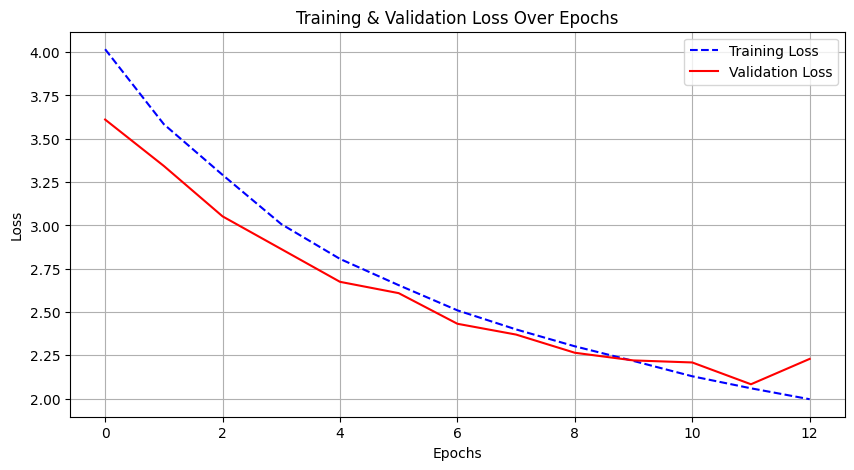

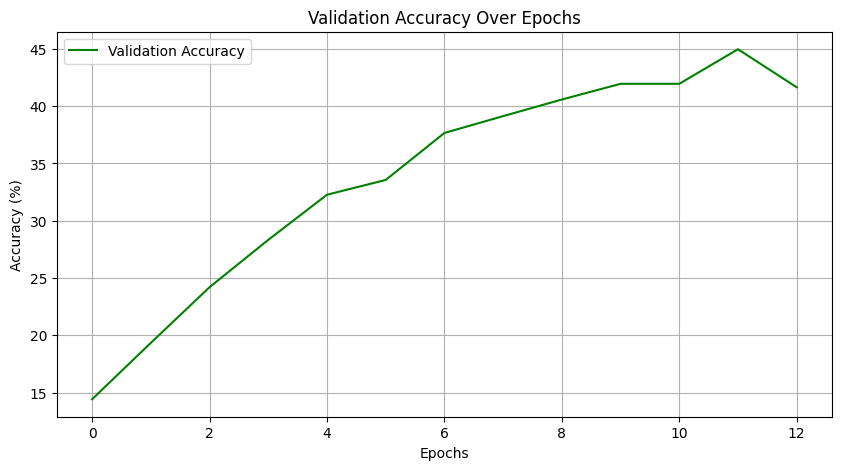

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Load the stored training results
train_losses = np.load("train_losses.npy")
val_losses = np.load("val_losses.npy")
val_accuracies = np.load("val_accuracies.npy")

# Plot Training & Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', color='blue', linestyle='dashed')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Plot Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy Over Epochs')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Define transformations for the training and testing datasets
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Horizontal flipping
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Color jittering
    transforms.RandomCrop(32, padding=4),  # Randomly crop the image
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),  # Normalize with CIFAR-100 mean and std
])

transform_test = transforms.Compose([
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),  # Normalize with CIFAR-100 mean and std
])

# Load the CIFAR-100 training dataset
train_dataset = datasets.CIFAR100(
    root='./data',  # Path to store the dataset
    train=True,  # Load the training set
    download=True,  # Download the dataset if it doesn't exist
    transform=transform_train,  # Apply the training transformations
)

# Load the CIFAR-100 testing dataset
test_dataset = datasets.CIFAR100(
    root='./data',  # Path to store the dataset
    train=False,  # Load the testing set
    download=True,  # Download the dataset if it doesn't exist
    transform=transform_test,  # Apply the testing transformations
)

# Split the training dataset into training and validation subsets
train_size = int(0.8 * len(train_dataset))  # 80% for training
val_size = len(train_dataset) - train_size  # 20% for validation
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# Create DataLoaders for training, validation, and testing
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Define the CNN model
class CNN(nn.Module):
    def __init__(self, activation='relu', kernel_size=3, num_classes=100):
        super(CNN, self).__init__()
        self.activation = activation
        self.conv1 = nn.Conv2d(3, 32, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
        self.bn4 = nn.BatchNorm2d(256)
        self.fc1 = nn.Linear(256 * 8 * 8, 1024)
        self.fc2 = nn.Linear(1024, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.apply_activation(self.bn1(self.conv1(x)))
        x = self.pool(self.apply_activation(self.bn2(self.conv2(x))))
        x = self.apply_activation(self.bn3(self.conv3(x)))
        x = self.pool(self.apply_activation(self.bn4(self.conv4(x))))
        x = x.view(x.size(0), -1)  # Flatten
        x = self.dropout(self.apply_activation(self.fc1(x)))
        x = self.fc2(x)
        return x

    def apply_activation(self, x):
        if self.activation == 'relu':
            return F.relu(x)
        elif self.activation == 'leaky_relu':
            return F.leaky_relu(x, negative_slope=0.1)
        elif self.activation == 'gelu':
            return F.gelu(x)
        else:
            raise ValueError(f"Unsupported activation: {self.activation}")

# Hyperparameters to tune
activations = [ 'gelu']
kernel_sizes = [ 5]
optimizers_list = [ 'sgd']

# Store results
results = []

# Hyperparameter tuning loop
for activation in activations:
    for kernel_size in kernel_sizes:
        for optimizer_name in optimizers_list:
            print(f"\nTraining with activation={activation}, kernel_size={kernel_size}, optimizer={optimizer_name}")

            # Create the model
            model = CNN(activation=activation, kernel_size=kernel_size, num_classes=100).to(device)

            # Define loss function and optimizer
            criterion = nn.CrossEntropyLoss()
            if optimizer_name == 'adam':
                optimizer = optim.Adam(model.parameters(), lr=0.001)
            elif optimizer_name == 'sgd':
                optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
            else:
                raise ValueError(f"Unsupported optimizer: {optimizer_name}")

            scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)

            # Training loop
            num_epochs = 50  # Train for fewer epochs for tuning
            best_val_accuracy = 0.0

            for epoch in range(num_epochs):
                model.train()
                running_loss = 0.0
                correct = 0
                total = 0

                for inputs, labels in train_loader:
                    inputs, labels = inputs.to(device), labels.to(device)

                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()

                    running_loss += loss.item()

                    _, predicted = torch.max(outputs, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

                train_loss = running_loss / len(train_loader)
                train_accuracy = 100 * correct / total

                # Validation loop
                model.eval()
                val_loss = 0.0
                correct = 0
                total = 0

                with torch.no_grad():
                    for inputs, labels in val_loader:
                        inputs, labels = inputs.to(device), labels.to(device)

                        outputs = model(inputs)
                        loss = criterion(outputs, labels)
                        val_loss += loss.item()

                        _, predicted = torch.max(outputs, 1)
                        total += labels.size(0)
                        correct += (predicted == labels).sum().item()

                val_loss = val_loss / len(val_loader)
                val_accuracy = 100 * correct / total

                # Save the best validation accuracy
                if val_accuracy > best_val_accuracy:
                    best_val_accuracy = val_accuracy

                print(f"Epoch [{epoch+1}/{num_epochs}], "
                      f"Training Loss: {train_loss:.4f}, "
                      f"Validation Loss: {val_loss:.4f}, "
                      f"Validation Accuracy: {val_accuracy:.2f}%")

                # Step the learning rate scheduler
                scheduler.step(val_loss)

            # Store the results
            results.append({
                'activation': activation,
                'kernel_size': kernel_size,
                'optimizer': optimizer_name,
                'best_val_accuracy': best_val_accuracy
            })

# Print the results
print("\nHyperparameter Tuning Results:")
for result in results:
    print(result)

# Find the best model
best_result = max(results, key=lambda x: x['best_val_accuracy'])
print(f"\nBest Model: {best_result}")

Using device: cuda

Training with activation=gelu, kernel_size=5, optimizer=sgd
Epoch [1/50], Training Loss: 4.0089, Validation Loss: 3.6558, Validation Accuracy: 13.93%
Epoch [2/50], Training Loss: 3.5497, Validation Loss: 3.2464, Validation Accuracy: 20.96%
Epoch [3/50], Training Loss: 3.2309, Validation Loss: 3.0356, Validation Accuracy: 25.17%
Epoch [4/50], Training Loss: 2.9520, Validation Loss: 2.9111, Validation Accuracy: 27.18%
Epoch [5/50], Training Loss: 2.7335, Validation Loss: 2.5851, Validation Accuracy: 33.61%
Epoch [6/50], Training Loss: 2.5677, Validation Loss: 2.4664, Validation Accuracy: 36.38%
Epoch [7/50], Training Loss: 2.4014, Validation Loss: 2.5264, Validation Accuracy: 35.32%
Epoch [8/50], Training Loss: 2.2835, Validation Loss: 2.2287, Validation Accuracy: 41.55%
Epoch [9/50], Training Loss: 2.1771, Validation Loss: 2.1104, Validation Accuracy: 43.58%
Epoch [10/50], Training Loss: 2.0817, Validation Loss: 2.0818, Validation Accuracy: 44.45%
Epoch [11/50], Trai

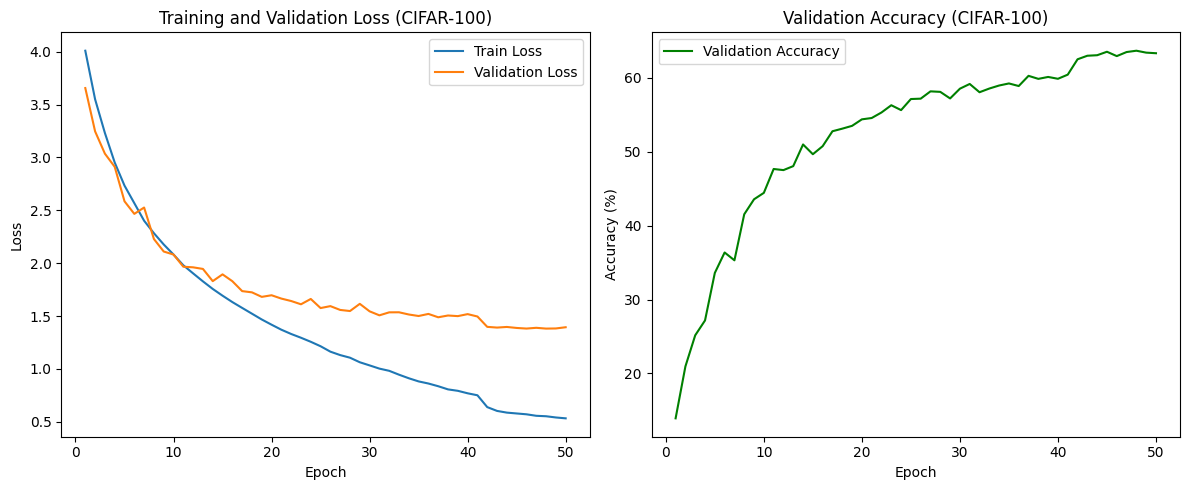

In [ ]:
import matplotlib.pyplot as plt

# Epochs
epochs = list(range(1, 51))

# Training and validation losses
train_losses = [
    4.0089, 3.5497, 3.2309, 2.9520, 2.7335, 2.5677, 2.4014, 2.2835, 2.1771, 2.0817,
    1.9803, 1.9037, 1.8282, 1.7567, 1.6929, 1.6325, 1.5773, 1.5227, 1.4679, 1.4186,
    1.3712, 1.3308, 1.2953, 1.2570, 1.2149, 1.1637, 1.1313, 1.1066, 1.0635, 1.0338,
    1.0034, 0.9826, 0.9460, 0.9122, 0.8824, 0.8625, 0.8369, 0.8070, 0.7935, 0.7701,
    0.7513, 0.6395, 0.6035, 0.5874, 0.5794, 0.5715, 0.5574, 0.5531, 0.5415, 0.5333
]

val_losses = [
    3.6558, 3.2464, 3.0356, 2.9111, 2.5851, 2.4664, 2.5264, 2.2287, 2.1104, 2.0818,
    1.9668, 1.9610, 1.9458, 1.8305, 1.8945, 1.8298, 1.7361, 1.7244, 1.6817, 1.6970,
    1.6654, 1.6425, 1.6116, 1.6620, 1.5759, 1.5942, 1.5582, 1.5478, 1.6158, 1.5450,
    1.5072, 1.5354, 1.5360, 1.5150, 1.5008, 1.5205, 1.4888, 1.5056, 1.4997, 1.5186,
    1.4961, 1.3982, 1.3914, 1.3973, 1.3879, 1.3821, 1.3892, 1.3818, 1.3831, 1.3946
]

val_accuracies = [
    13.93, 20.96, 25.17, 27.18, 33.61, 36.38, 35.32, 41.55, 43.58, 44.45,
    47.68, 47.53, 48.07, 51.00, 49.68, 50.77, 52.79, 53.14, 53.52, 54.40,
    54.58, 55.33, 56.31, 55.65, 57.15, 57.20, 58.19, 58.12, 57.23, 58.55,
    59.19, 58.07, 58.57, 58.98, 59.26, 58.91, 60.29, 59.88, 60.14, 59.89,
    60.45, 62.53, 63.01, 63.08, 63.55, 62.96, 63.51, 63.69, 63.43, 63.35
]

# Plot the metrics
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss (CIFAR-100)')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy (CIFAR-100)')
plt.legend()

plt.tight_layout()
plt.show()
